In [3]:
!git clone https://github.com/AbdelrahmanAdel-1/MNIST-ML-ImageClassifiers.git
%cd MNIST-ML-ImageClassifiers

# Configure Git identity
!git config --global user.name "loaymahmoud10"
!git config --global user.email "lorarri911@gmail.com"

# Pull latest changes from main
!git pull origin main

Cloning into 'MNIST-ML-ImageClassifiers'...
remote: Enumerating objects: 148, done.
remote: Counting objects: 100% (148/148), done.
remote: Compressing objects: 100% (121/121), done.
remote: Total 148 (delta 55), reused 89 (delta 23), pack-reused 0 (from 0)
Receiving objects: 100% (148/148), 787.18 KiB | 7.57 MiB/s, done.
Resolving deltas: 100% (55/55), done.
/content/MNIST-ML-ImageClassifiers/MNIST-ML-ImageClassifiers/MNIST-ML-ImageClassifiers
error: pathspec 'LogisticRegression' did not match any file(s) known to git
From https://github.com/AbdelrahmanAdel-1/MNIST-ML-ImageClassifiers
 * branch            main       -> FETCH_HEAD
Already up to date.


In [4]:
!ls

evaluation		   models     preprocessing  report
MNIST-ML-ImageClassifiers  notebooks  README.md      results


In [5]:
!ls preprocessing

preprocess.py


In [6]:
from preprocessing.preprocess import preprocess

X_tr, X_val, X_test, y_tr, y_val, y_test = preprocess(
    feature_method='flatten',
    binary=True,
    positive_class=1
)

 Starting Preprocessing Pipeline...
   Feature method : flatten
   Mode           : Binary

 Loading data...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
 MNIST Dataset Loaded Successfully!
   Training images  : (60000, 28, 28)
   Training labels  : (60000,)
   Test images      : (10000, 28, 28)
   Test labels      : (10000,)

  Encoding labels...
 Labels encoded — Positive class: Digit 1
   Training — Positive samples : 6742
   Training — Negative samples : 53258
   Test     — Positive samples : 1135
   Test     — Negative samples : 8865

 Normalizing pixels...
 Pixel values normalized to [0, 1]

 Extracting features using FLATTEN...
 Images flattened successfully!
   Training shape : (60000, 784)
   Test shape     : (10000, 784)

  Splitting data...
 Train/Validation split done!
   Training   samples : 48000
   Validation samples : 12000

 Standardizing features...
 Features standardized successfully!
   Training mean (should be ~0) : 0.0000
   Training std  (should be ~1) : 0.

# **Model**

In [7]:
%%writefile models/logistic_regression.py
import numpy as np

class LogisticRegression:
    def __init__(self, lr=0.01, epochs=1000, lambda_=0.01):
        self.lr = lr
        self.epochs = epochs
        self.lambda_ = lambda_
        self.w = None
        self.b = 0
        self.loss_history = []

    def sigmoid(self, z):
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))

    def compute_loss(self, y, y_pred, n_samples):
        loss = -np.mean(
            y * np.log(y_pred + 1e-15) +
            (1 - y) * np.log(1 - y_pred + 1e-15)
        )
        # L2 regularization (exclude bias)
        loss += (self.lambda_ / (2 * n_samples)) * np.sum(self.w ** 2)
        return loss

    def fit(self, X, y):
        n_samples, n_features = X.shape

        # stable initialization
        self.w = np.random.randn(n_features) * 0.01
        self.b = 0

        for _ in range(self.epochs):
            # forward pass
            linear = np.dot(X, self.w) + self.b
            y_pred = self.sigmoid(linear)

            # loss tracking
            loss = self.compute_loss(y, y_pred, n_samples)
            self.loss_history.append(loss)

            # gradients
            dw = (1 / n_samples) * np.dot(X.T, (y_pred - y))
            db = (1 / n_samples) * np.sum(y_pred - y)

            # L2 regularization
            dw += (self.lambda_ / n_samples) * self.w

            # update
            self.w -= self.lr * dw
            self.b -= self.lr * db

            # improved early stopping
            if len(self.loss_history) > 1:
                if abs(self.loss_history[-1] - self.loss_history[-2]) < 1e-7:
                    break

    def predict_proba(self, X):
        return self.sigmoid(np.dot(X, self.w) + self.b)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

    def summary(self):
        print("Logistic Regression Model")
        print(f"Learning rate: {self.lr}")
        print(f"Epochs: {self.epochs}")
        print(f"Lambda: {self.lambda_}")
        print(f"Final loss: {self.loss_history[-1] if self.loss_history else None}")

Writing models/logistic_regression.py


In [8]:
!ls models

logistic_regression.py	svm.py


In [9]:
import importlib
import models.logistic_regression

importlib.reload(models.logistic_regression)

<module 'models.logistic_regression' from '/content/MNIST-ML-ImageClassifiers/MNIST-ML-ImageClassifiers/MNIST-ML-ImageClassifiers/models/logistic_regression.py'>

In [10]:
from models.logistic_regression import LogisticRegression

In [11]:
model = LogisticRegression(lr=0.01, epochs=1000, lambda_=0.01)
model.fit(X_tr, y_tr)
y_pred = model.predict(X_test)

 Classification Report — Logistic Regression (L2) - Baseline (thr=0.5)
  Accuracy  : 0.9790  (97.90%)
  Precision : 0.8645
  Recall    : 0.9665
  F1-Score  : 0.9126
--------------------------------------------------
  TP : 1097  |  FP : 172
  FN : 38  |  TN : 8693


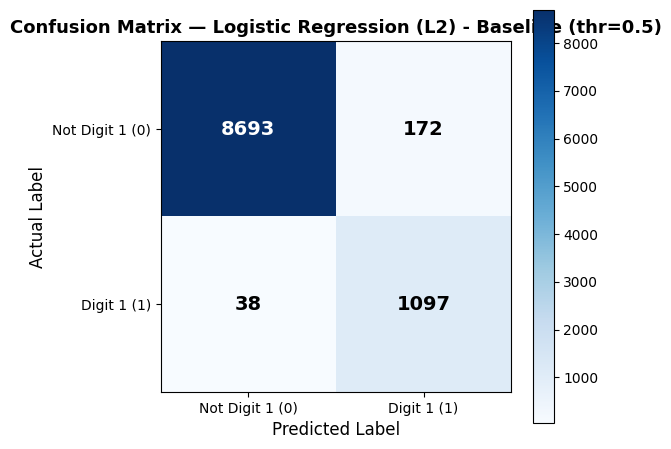

In [12]:
from evaluation.metrics import evaluate

results_baseline = evaluate(
    y_test, y_pred,
    model_name="Logistic Regression (L2) - Baseline (thr=0.5)"
)

In [13]:
import json

with open("results/logreg_baseline_model.json", "w") as f:
    json.dump(results_baseline, f)

# **Tuning Threshold**

In [14]:
probs = model.predict_proba(X_test)


Threshold: 0.4
 Classification Report — LogReg (L2, thr=0.4)
  Accuracy  : 0.9667  (96.67%)
  Precision : 0.7816
  Recall    : 0.9806
  F1-Score  : 0.8699
--------------------------------------------------
  TP : 1113  |  FP : 311
  FN : 22  |  TN : 8554


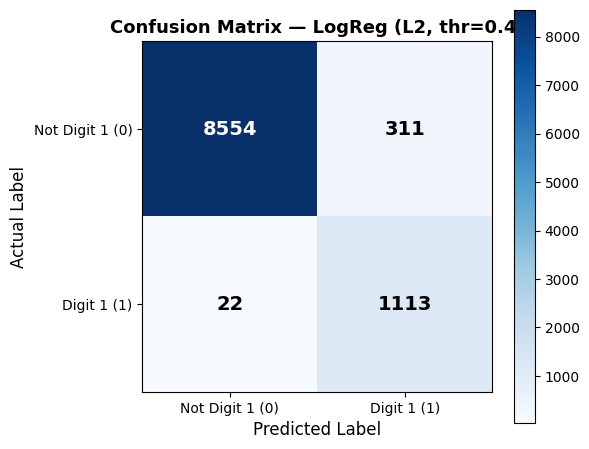


Threshold: 0.5
 Classification Report — LogReg (L2, thr=0.5)
  Accuracy  : 0.9790  (97.90%)
  Precision : 0.8645
  Recall    : 0.9665
  F1-Score  : 0.9126
--------------------------------------------------
  TP : 1097  |  FP : 172
  FN : 38  |  TN : 8693


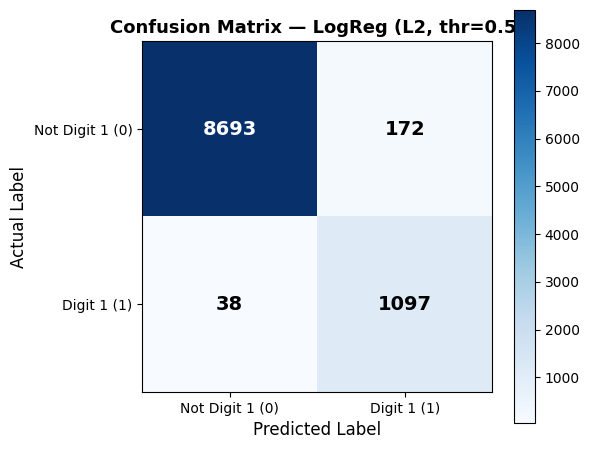


Threshold: 0.6
 Classification Report — LogReg (L2, thr=0.6)
  Accuracy  : 0.9851  (98.51%)
  Precision : 0.9265
  Recall    : 0.9436
  F1-Score  : 0.9350
--------------------------------------------------
  TP : 1071  |  FP : 85
  FN : 64  |  TN : 8780


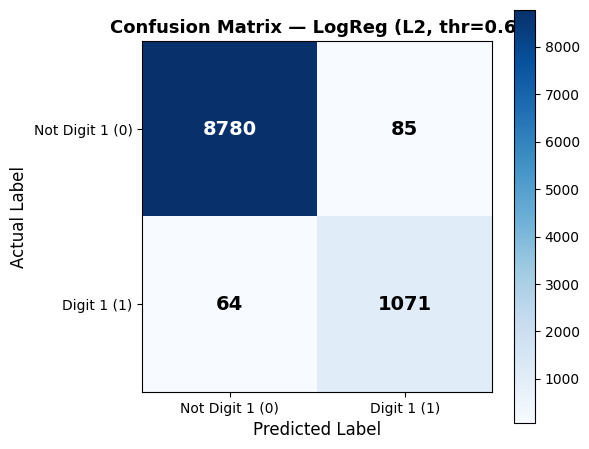


Threshold: 0.7
 Classification Report — LogReg (L2, thr=0.7)
  Accuracy  : 0.9861  (98.61%)
  Precision : 0.9663
  Recall    : 0.9093
  F1-Score  : 0.9369
--------------------------------------------------
  TP : 1032  |  FP : 36
  FN : 103  |  TN : 8829


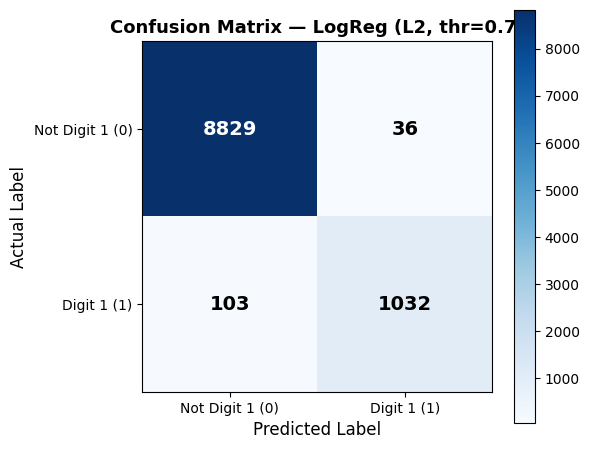

In [15]:
from evaluation.metrics import evaluate
import json

results_thr = {}

for t in [0.4, 0.5, 0.6, 0.7]:
    y_pred_t = (probs >= t).astype(int)

    print("\nThreshold:", t)

    res = evaluate(
        y_test,
        y_pred_t,
        model_name=f"LogReg (L2, thr={t})"
    )

    # store in dictionary
    results_thr[f"thr_{t}"] = res

In [16]:
with open("results/logreg_threshold_tuning.json", "w") as f:
    json.dump(results_thr, f)

In [17]:
print("===== THRESHOLD RESULTS =====")
print(results_thr)

===== THRESHOLD RESULTS =====
{'thr_0.4': {'model': 'LogReg (L2, thr=0.4)', 'accuracy': np.float64(0.9667), 'precision': np.float64(0.7816011235955056), 'recall': np.float64(0.9806167400881057), 'f1_score': np.float64(0.8698710433763188)}, 'thr_0.5': {'model': 'LogReg (L2, thr=0.5)', 'accuracy': np.float64(0.979), 'precision': np.float64(0.8644602048857368), 'recall': np.float64(0.9665198237885463), 'f1_score': np.float64(0.9126455906821963)}, 'thr_0.6': {'model': 'LogReg (L2, thr=0.6)', 'accuracy': np.float64(0.9851), 'precision': np.float64(0.9264705882352942), 'recall': np.float64(0.9436123348017621), 'f1_score': np.float64(0.9349628982976868)}, 'thr_0.7': {'model': 'LogReg (L2, thr=0.7)', 'accuracy': np.float64(0.9861), 'precision': np.float64(0.9662921348314607), 'recall': np.float64(0.9092511013215859), 'f1_score': np.float64(0.9369042215161145)}}


# **Tuning Features**

In [18]:
X_tr, X_val, X_test, y_tr, y_val, y_test = preprocess(
    feature_method='flatten',
    binary=True,
    positive_class=1
)

 Starting Preprocessing Pipeline...
   Feature method : flatten
   Mode           : Binary

 Loading data...
 MNIST Dataset Loaded Successfully!
   Training images  : (60000, 28, 28)
   Training labels  : (60000,)
   Test images      : (10000, 28, 28)
   Test labels      : (10000,)

  Encoding labels...
 Labels encoded — Positive class: Digit 1
   Training — Positive samples : 6742
   Training — Negative samples : 53258
   Test     — Positive samples : 1135
   Test     — Negative samples : 8865

 Normalizing pixels...
 Pixel values normalized to [0, 1]

 Extracting features using FLATTEN...
 Images flattened successfully!
   Training shape : (60000, 784)
   Test shape     : (10000, 784)

  Splitting data...
 Train/Validation split done!
   Training   samples : 48000
   Validation samples : 12000

 Standardizing features...
 Features standardized successfully!
   Training mean (should be ~0) : 0.0000
   Training std  (should be ~1) : 0.9536

 Preprocessing Pipeline Complete!
   X_tr   :

In [19]:
model = LogisticRegression(lr=0.01, epochs=1000, lambda_=0.01)
model.fit(X_tr, y_tr)

In [20]:
probs = model.predict_proba(X_test)
y_pred = (probs >= 0.6).astype(int)

 Classification Report — Flatten + Logistic (L2)
  Accuracy  : 0.9851  (98.51%)
  Precision : 0.9265
  Recall    : 0.9436
  F1-Score  : 0.9350
--------------------------------------------------
  TP : 1071  |  FP : 85
  FN : 64  |  TN : 8780


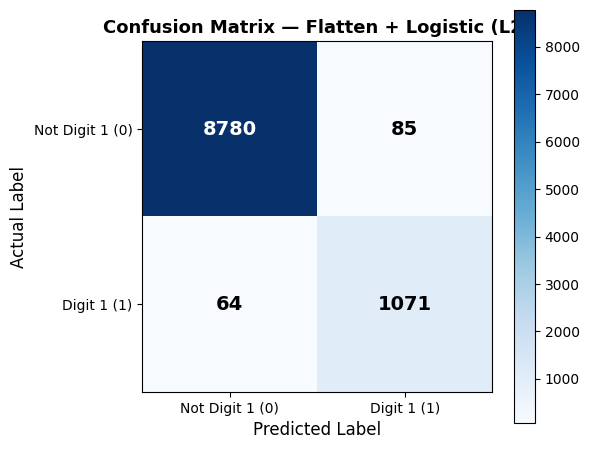

In [21]:
from evaluation.metrics import evaluate

results_flatten = evaluate(y_test, y_pred, model_name="Flatten + Logistic (L2)")

In [22]:
import json

with open("results/logreg_flatten_tuning.json", "w") as f:
    json.dump(results_flatten, f)

In [23]:
X_tr, X_val, X_test, y_tr, y_val, y_test = preprocess(
    feature_method='pca',
    pca_components=50
)

 Starting Preprocessing Pipeline...
   Feature method : pca
   Mode           : Binary

 Loading data...
 MNIST Dataset Loaded Successfully!
   Training images  : (60000, 28, 28)
   Training labels  : (60000,)
   Test images      : (10000, 28, 28)
   Test labels      : (10000,)

  Encoding labels...
 Labels encoded — Positive class: Digit 1
   Training — Positive samples : 6742
   Training — Negative samples : 53258
   Test     — Positive samples : 1135
   Test     — Negative samples : 8865

 Normalizing pixels...
 Pixel values normalized to [0, 1]

 Extracting features using PCA...
 Images flattened successfully!
   Training shape : (60000, 784)
   Test shape     : (10000, 784)
PCA applied successfully!
   Components kept    : 50
   Training shape     : (60000, 50)
   Test shape         : (10000, 50)
   Variance explained : 82.46%

  Splitting data...
 Train/Validation split done!
   Training   samples : 48000
   Validation samples : 12000

 Standardizing features...
 Features standar

In [24]:
model = LogisticRegression(lr=0.01, epochs=1000, lambda_=0.01)
model.fit(X_tr, y_tr)

In [25]:
probs = model.predict_proba(X_test)
y_pred = (probs >= 0.6).astype(int)

 Classification Report — PCA + Logistic (L2)
  Accuracy  : 0.9801  (98.01%)
  Precision : 0.9815
  Recall    : 0.8405
  F1-Score  : 0.9056
--------------------------------------------------
  TP : 954  |  FP : 18
  FN : 181  |  TN : 8847


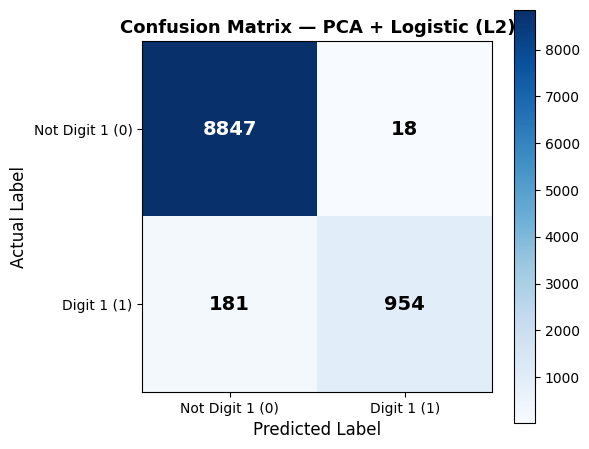

In [26]:
results_pca = evaluate(y_test, y_pred, model_name="PCA + Logistic (L2)")

In [27]:
import json

with open("results/logreg_pca50_tuning.json", "w") as f:
    json.dump(results_pca, f)

In [28]:
X_tr, X_val, X_test, y_tr, y_val, y_test = preprocess(
    feature_method='hog'
)

 Starting Preprocessing Pipeline...
   Feature method : hog
   Mode           : Binary

 Loading data...
 MNIST Dataset Loaded Successfully!
   Training images  : (60000, 28, 28)
   Training labels  : (60000,)
   Test images      : (10000, 28, 28)
   Test labels      : (10000,)

  Encoding labels...
 Labels encoded — Positive class: Digit 1
   Training — Positive samples : 6742
   Training — Negative samples : 53258
   Test     — Positive samples : 1135
   Test     — Negative samples : 8865

 Normalizing pixels...
 Pixel values normalized to [0, 1]

 Extracting features using HOG...
 HOG features extracted successfully!
   Input shape  : (60000, 28, 28)
   Output shape : (60000, 441)
 HOG features extracted successfully!
   Input shape  : (10000, 28, 28)
   Output shape : (10000, 441)

  Splitting data...
 Train/Validation split done!
   Training   samples : 48000
   Validation samples : 12000

 Standardizing features...
 Features standardized successfully!
   Training mean (should be 

In [29]:
model = LogisticRegression(lr=0.01, epochs=1000, lambda_=0.01)
model.fit(X_tr, y_tr)

In [30]:
probs = model.predict_proba(X_test)
y_pred = (probs >= 0.6).astype(int)

 Classification Report — HOG + Logistic (L2)
  Accuracy  : 0.9911  (99.11%)
  Precision : 0.9580
  Recall    : 0.9639
  F1-Score  : 0.9609
--------------------------------------------------
  TP : 1094  |  FP : 48
  FN : 41  |  TN : 8817


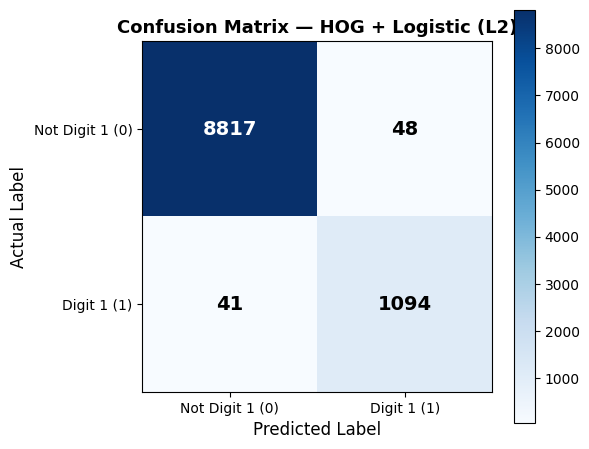

In [31]:
from evaluation.metrics import evaluate

results_hog = evaluate(y_test, y_pred, model_name="HOG + Logistic (L2)")

In [32]:
import json

with open("results/logreg_hog_tuning.json", "w") as f:
    json.dump(results_hog, f)

In [33]:
print("===== FLATTEN RESULTS =====")
print(results_flatten)

print("\n===== PCA RESULTS =====")
print(results_pca)

print("\n===== HOG RESULTS =====")
print(results_hog)

===== FLATTEN RESULTS =====
{'model': 'Flatten + Logistic (L2)', 'accuracy': np.float64(0.9851), 'precision': np.float64(0.9264705882352942), 'recall': np.float64(0.9436123348017621), 'f1_score': np.float64(0.9349628982976868)}

===== PCA RESULTS =====
{'model': 'PCA + Logistic (L2)', 'accuracy': np.float64(0.9801), 'precision': np.float64(0.9814814814814815), 'recall': np.float64(0.8405286343612335), 'f1_score': np.float64(0.9055529188419553)}

===== HOG RESULTS =====
{'model': 'HOG + Logistic (L2)', 'accuracy': np.float64(0.9911), 'precision': np.float64(0.957968476357268), 'recall': np.float64(0.9638766519823788), 'f1_score': np.float64(0.9609134826526131)}


# **Tuning Regularization Strength**

In [34]:
X_tr_hog, X_val_hog, X_test_hog, y_tr_hog, y_val_hog, y_test_hog = preprocess(
    feature_method='hog',
    binary=True,
    positive_class=1
)

 Starting Preprocessing Pipeline...
   Feature method : hog
   Mode           : Binary

 Loading data...
 MNIST Dataset Loaded Successfully!
   Training images  : (60000, 28, 28)
   Training labels  : (60000,)
   Test images      : (10000, 28, 28)
   Test labels      : (10000,)

  Encoding labels...
 Labels encoded — Positive class: Digit 1
   Training — Positive samples : 6742
   Training — Negative samples : 53258
   Test     — Positive samples : 1135
   Test     — Negative samples : 8865

 Normalizing pixels...
 Pixel values normalized to [0, 1]

 Extracting features using HOG...
 HOG features extracted successfully!
   Input shape  : (60000, 28, 28)
   Output shape : (60000, 441)
 HOG features extracted successfully!
   Input shape  : (10000, 28, 28)
   Output shape : (10000, 441)

  Splitting data...
 Train/Validation split done!
   Training   samples : 48000
   Validation samples : 12000

 Standardizing features...
 Features standardized successfully!
   Training mean (should be 


Lambda: 0
 Classification Report — HOG + LogReg (L2 λ=0, thr=0.6)
  Accuracy  : 0.9911  (99.11%)
  Precision : 0.9580
  Recall    : 0.9639
  F1-Score  : 0.9609
--------------------------------------------------
  TP : 1094  |  FP : 48
  FN : 41  |  TN : 8817


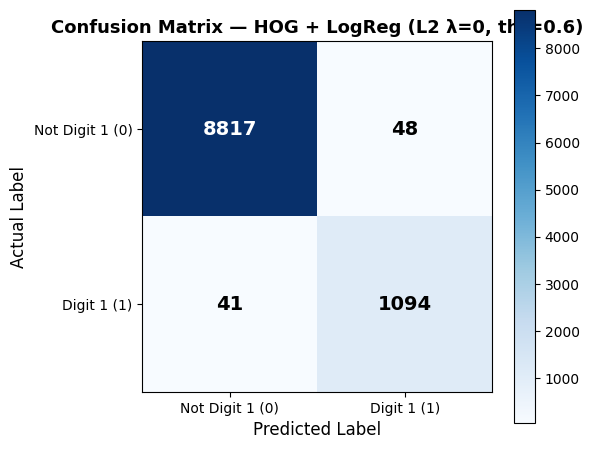


Lambda: 0.001
 Classification Report — HOG + LogReg (L2 λ=0.001, thr=0.6)
  Accuracy  : 0.9910  (99.10%)
  Precision : 0.9571
  Recall    : 0.9639
  F1-Score  : 0.9605
--------------------------------------------------
  TP : 1094  |  FP : 49
  FN : 41  |  TN : 8816


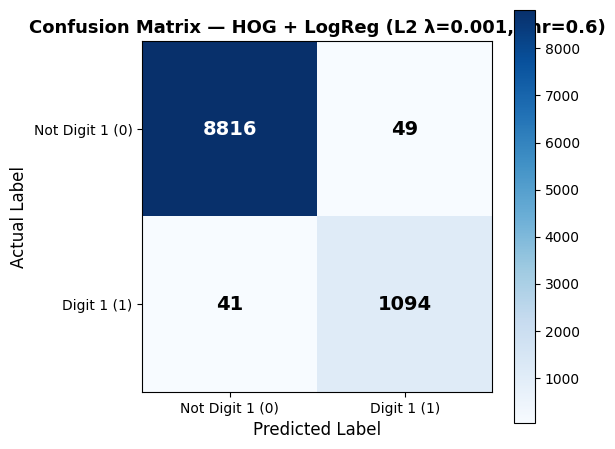


Lambda: 0.01
 Classification Report — HOG + LogReg (L2 λ=0.01, thr=0.6)
  Accuracy  : 0.9911  (99.11%)
  Precision : 0.9588
  Recall    : 0.9630
  F1-Score  : 0.9609
--------------------------------------------------
  TP : 1093  |  FP : 47
  FN : 42  |  TN : 8818


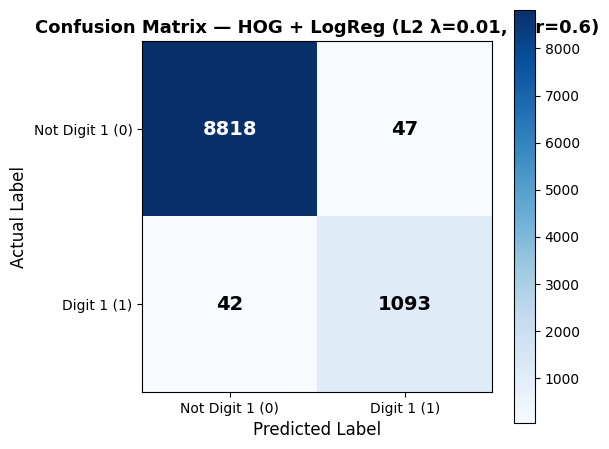


Lambda: 0.1
 Classification Report — HOG + LogReg (L2 λ=0.1, thr=0.6)
  Accuracy  : 0.9911  (99.11%)
  Precision : 0.9588
  Recall    : 0.9630
  F1-Score  : 0.9609
--------------------------------------------------
  TP : 1093  |  FP : 47
  FN : 42  |  TN : 8818


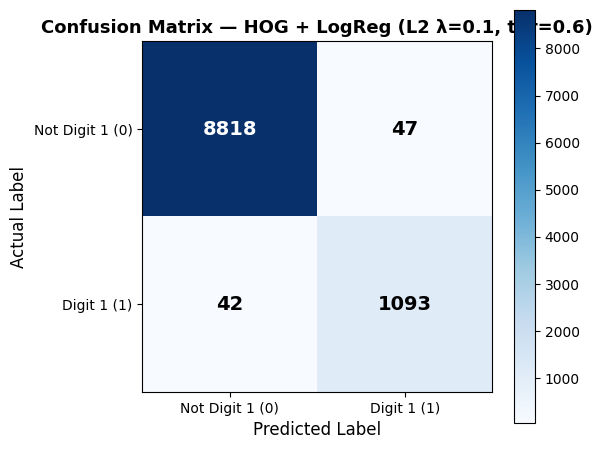

In [35]:
from evaluation.metrics import evaluate
import json

lambdas = [0, 0.001, 0.01, 0.1]
results_lambda = {}

for l in lambdas:
    print("\nLambda:", l)

    # rebuild model each time
    model = LogisticRegression(lr=0.01, epochs=1000, lambda_=l)

    model.fit(X_tr_hog, y_tr_hog)

    probs = model.predict_proba(X_test_hog)
    y_pred = (probs >= 0.6).astype(int)

    res = evaluate(
        y_test_hog,
        y_pred,
        model_name=f"HOG + LogReg (L2 λ={l}, thr=0.6)"
    )

    results_lambda[f"lambda_{l}"] = res

In [36]:
import json

with open("results/logreg_lambda_tuning.json", "w") as f:
    json.dump(results_lambda, f)

In [37]:
import os

print("MODELS:")
print(os.listdir("models"))

print("\nRESULTS:")
print(os.listdir("results"))

['logreg_flatten_tuning.json', 'logreg_pca50_tuning.json', 'logreg_hog_tuning.json', 'logreg_threshold_tuning.json', 'svm_loss_curves.png', '.gitkeep', 'logreg_lambda_tuning.json', 'svm_results.csv', 'logreg_baseline_model.json', 'svm_confusion_matrices.png']


In [40]:
!git checkout -b LogisticRegression

Switched to a new branch 'LogisticRegression'


In [41]:
!git branch

* LogisticRegression
  main


In [42]:
!git status

On branch LogisticRegression
Untracked files:
  (use "git add <file>..." to include in what will be committed)
	models/logistic_regression.py
	results/logreg_baseline_model.json
	results/logreg_flatten_tuning.json
	results/logreg_hog_tuning.json
	results/logreg_lambda_tuning.json
	results/logreg_pca50_tuning.json
	results/logreg_threshold_tuning.json

nothing added to commit but untracked files present (use "git add" to track)


In [43]:
!git add models/logistic_regression.py
!git add results/logreg_*.json

In [44]:
!git status

On branch LogisticRegression
Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	new file:   models/logistic_regression.py
	new file:   results/logreg_baseline_model.json
	new file:   results/logreg_flatten_tuning.json
	new file:   results/logreg_hog_tuning.json
	new file:   results/logreg_lambda_tuning.json
	new file:   results/logreg_pca50_tuning.json
	new file:   results/logreg_threshold_tuning.json



In [45]:
!git commit -m "Add Logistic Regression with feature engineering, lambda tuning, and threshold tuning results"

[LogisticRegression d51f447] Add Logistic Regression with feature engineering, lambda tuning, and threshold tuning results
 7 files changed, 74 insertions(+)
 create mode 100644 models/logistic_regression.py
 create mode 100644 results/logreg_baseline_model.json
 create mode 100644 results/logreg_flatten_tuning.json
 create mode 100644 results/logreg_hog_tuning.json
 create mode 100644 results/logreg_lambda_tuning.json
 create mode 100644 results/logreg_pca50_tuning.json
 create mode 100644 results/logreg_threshold_tuning.json


In [47]:
!git push https://mytoken@github.com/AbdelrahmanAdel-1/MNIST-ML-ImageClassifiers.git LogisticRegression

Enumerating objects: 14, done.
Counting objects: 100% (14/14), done.
Delta compression using up to 2 threads
Compressing objects: 100% (11/11), done.
Writing objects: 100% (11/11), 2.58 KiB | 1.29 MiB/s, done.
Total 11 (delta 1), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (1/1), completed with 1 local object.
remote: 
remote: Create a pull request for 'LogisticRegression' on GitHub by visiting:
remote:      https://github.com/AbdelrahmanAdel-1/MNIST-ML-ImageClassifiers/pull/new/LogisticRegression
remote: 
To https://github.com/AbdelrahmanAdel-1/MNIST-ML-ImageClassifiers.git
 * [new branch]      LogisticRegression -> LogisticRegression


In [48]:
!git checkout main
!git pull origin main

Switched to branch 'main'
Your branch is up to date with 'origin/main'.
remote: Enumerating objects: 1, done.
remote: Counting objects: 100% (1/1), done.
remote: Total 1 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Unpacking objects: 100% (1/1), 947 bytes | 947.00 KiB/s, done.
From https://github.com/AbdelrahmanAdel-1/MNIST-ML-ImageClassifiers
 * branch            main       -> FETCH_HEAD
   5fcfdf3..4af2d21  main       -> origin/main
Updating 5fcfdf3..4af2d21
Fast-forward
 models/logistic_regression.py        | 68 ++++++++++++++++++++++++++++++++++++
 results/logreg_baseline_model.json   |  1 +
 results/logreg_flatten_tuning.json   |  1 +
 results/logreg_hog_tuning.json       |  1 +
 results/logreg_lambda_tuning.json    |  1 +
 results/logreg_pca50_tuning.json     |  1 +
 results/logreg_threshold_tuning.json |  1 +
 7 files changed, 74 insertions(+)
 create mode 100644 models/logistic_regression.py
 create mode 100644 results/logreg_baseline_model.json
 create mode 100644 res

In [49]:
!git log --oneline -5

4af2d21 (HEAD -> main, origin/main, origin/HEAD) Merge pull request #4 from AbdelrahmanAdel-1/LogisticRegression
d51f447 (LogisticRegression) Add Logistic Regression with feature engineering, lambda tuning, and threshold tuning results
5fcfdf3 Add files via upload
c950f70 Delete notebooks/Evaluation.ipynb
afa2707 Add files via upload
